# PBL Fase 5 — FarmTech Solutions
## Previsão de Rendimento Agrícola com Machine Learning Supervisionado e Não Supervisionado

**Aluno:** Giovana Agudo  
**RM:** 566773  
**Curso:** Inteligência Artificial  
**Projeto:** FarmTech Solutions  

---

## 1. Introdução

A FarmTech Solutions atua como consultoria de Inteligência Artificial para uma fazenda de médio porte, com aproximadamente 200 hectares de produção agrícola. O objetivo deste projeto é analisar uma base de dados contendo informações climáticas e ambientais relacionadas a diferentes culturas, a fim de gerar insights sobre produtividade e construir modelos preditivos capazes de estimar o rendimento das safras.

Este trabalho contempla duas frentes principais de Machine Learning:

- **Aprendizado Não Supervisionado:** identificar padrões de produtividade por meio de clusterização e detectar possíveis cenários discrepantes (outliers);
- **Aprendizado Supervisionado:** desenvolver modelos de regressão para prever o rendimento agrícola a partir das condições observadas.

Além da construção dos modelos, este notebook também apresenta a análise exploratória dos dados, o pré-processamento, a comparação entre algoritmos e a interpretação crítica dos resultados.

---

## 2. Objetivos

Os objetivos deste projeto são:

- Realizar uma análise exploratória da base de dados;
- Identificar padrões e agrupamentos entre cenários agrícolas;
- Detectar possíveis outliers;
- Construir **cinco modelos preditivos** com algoritmos diferentes para prever o rendimento da safra;
- Avaliar os modelos com métricas adequadas de regressão;
- Comparar os resultados e apontar limitações e oportunidades de melhoria.


In [1]:
# ============================
# 1. Importação das bibliotecas
# ============================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import zscore

# Configurações visuais
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Bibliotecas importadas com sucesso.")


Bibliotecas importadas com sucesso.


## 3. Carregamento da Base de Dados

Nesta etapa, será realizado o carregamento do arquivo `crop_yield.csv`, seguido de uma inspeção inicial para entender a estrutura da base.


In [2]:
# ============================
# 2. Carregamento da base
# ============================

df = pd.read_csv("crop_yield.csv")

print("Base carregada com sucesso.")
print(f"Quantidade de linhas: {df.shape[0]}")
print(f"Quantidade de colunas: {df.shape[1]}")


Base carregada com sucesso.
Quantidade de linhas: 156
Quantidade de colunas: 6


In [3]:
# Visualização inicial dos dados
df.head()


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [4]:
# Informações gerais da base
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


In [5]:
# Estatísticas descritivas
df.describe(include="all")


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156,156.000000,156.000000,156.000000,156.00000,156.000000
unique,4,NaN,NaN,NaN,NaN,NaN
top,"Cocoa, beans",NaN,NaN,NaN,NaN,NaN
freq,39,NaN,NaN,NaN,NaN,NaN
mean,NaN,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,NaN,289.457914,0.293923,0.996226,0.26105,70421.958897
min,NaN,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,NaN,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,NaN,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,NaN,2718.080000,18.400000,85.510000,26.30000,67518.750000


In [6]:
# Verificação de valores ausentes
df.isnull().sum()


Crop                                    0
Precipitation (mm day-1)                0
Specific Humidity at 2 Meters (g/kg)    0
Relative Humidity at 2 Meters (%)       0
Temperature at 2 Meters (C)             0
Yield                                   0
dtype: int64

## 4. Análise Exploratória dos Dados (EDA)

A análise exploratória tem como objetivo compreender o comportamento das variáveis, identificar padrões, verificar a distribuição dos dados e analisar possíveis relações entre os atributos e o rendimento da safra.


In [7]:
# Renomeando colunas para facilitar o uso no projeto
df.columns = [
    "Crop",
    "Precipitation",
    "Specific_Humidity",
    "Relative_Humidity",
    "Temperature",
    "Yield"
]

df.head()


,Crop,Precipitation,Specific_Humidity,Relative_Humidity,Temperature,Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


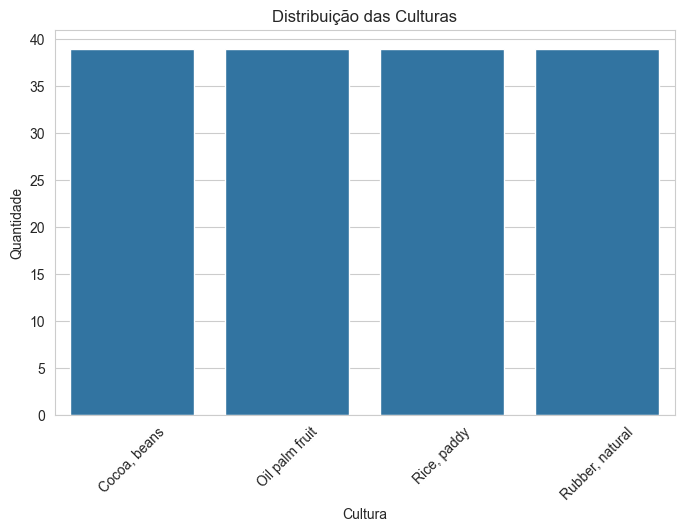

In [8]:
# Distribuição das culturas
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Crop", order=df["Crop"].value_counts().index)
plt.title("Distribuição das Culturas")
plt.xlabel("Cultura")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.show()


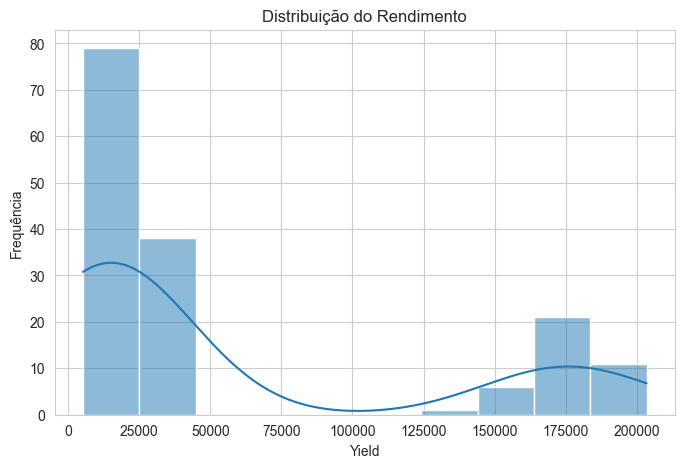

In [9]:
# Distribuição do rendimento
plt.figure(figsize=(8,5))
sns.histplot(df["Yield"], kde=True)
plt.title("Distribuição do Rendimento")
plt.xlabel("Yield")
plt.ylabel("Frequência")
plt.show()


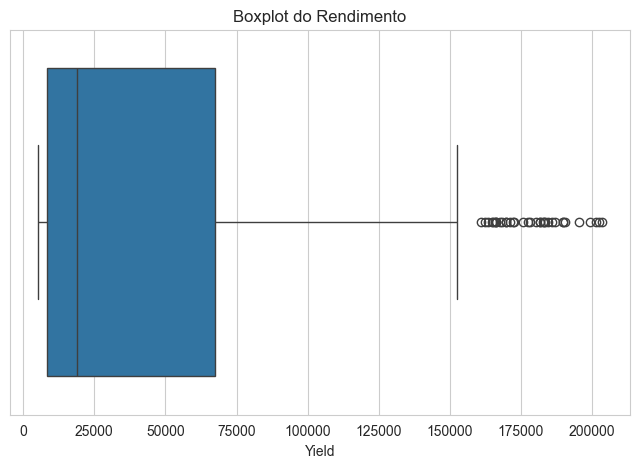

In [10]:
# Boxplot do rendimento para identificar possíveis outliers
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Yield")
plt.title("Boxplot do Rendimento")
plt.show()


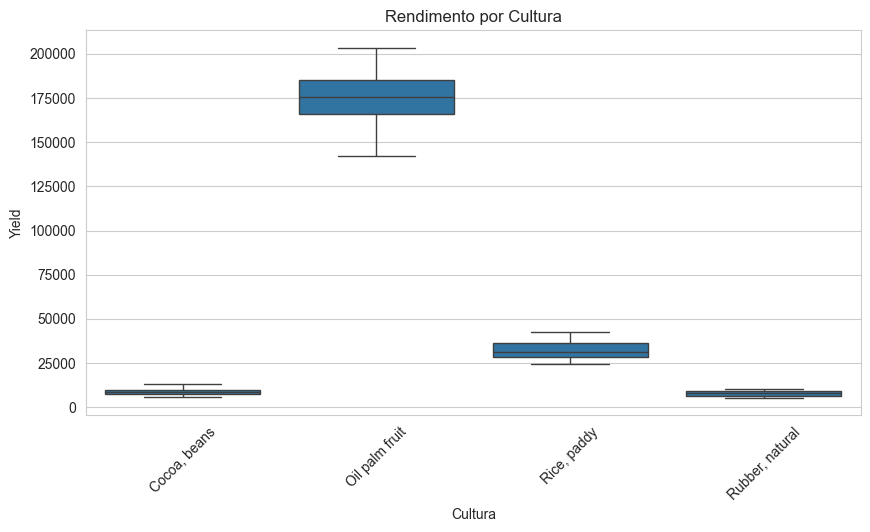

In [11]:
# Relação entre cultura e rendimento
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="Crop", y="Yield")
plt.title("Rendimento por Cultura")
plt.xlabel("Cultura")
plt.ylabel("Yield")
plt.xticks(rotation=45)
plt.show()


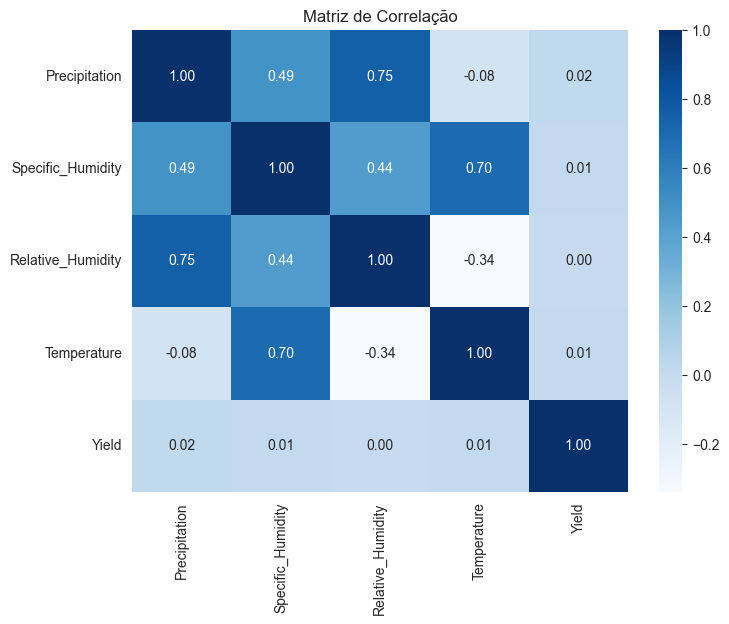

In [12]:
# Matriz de correlação (somente variáveis numéricas)
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()


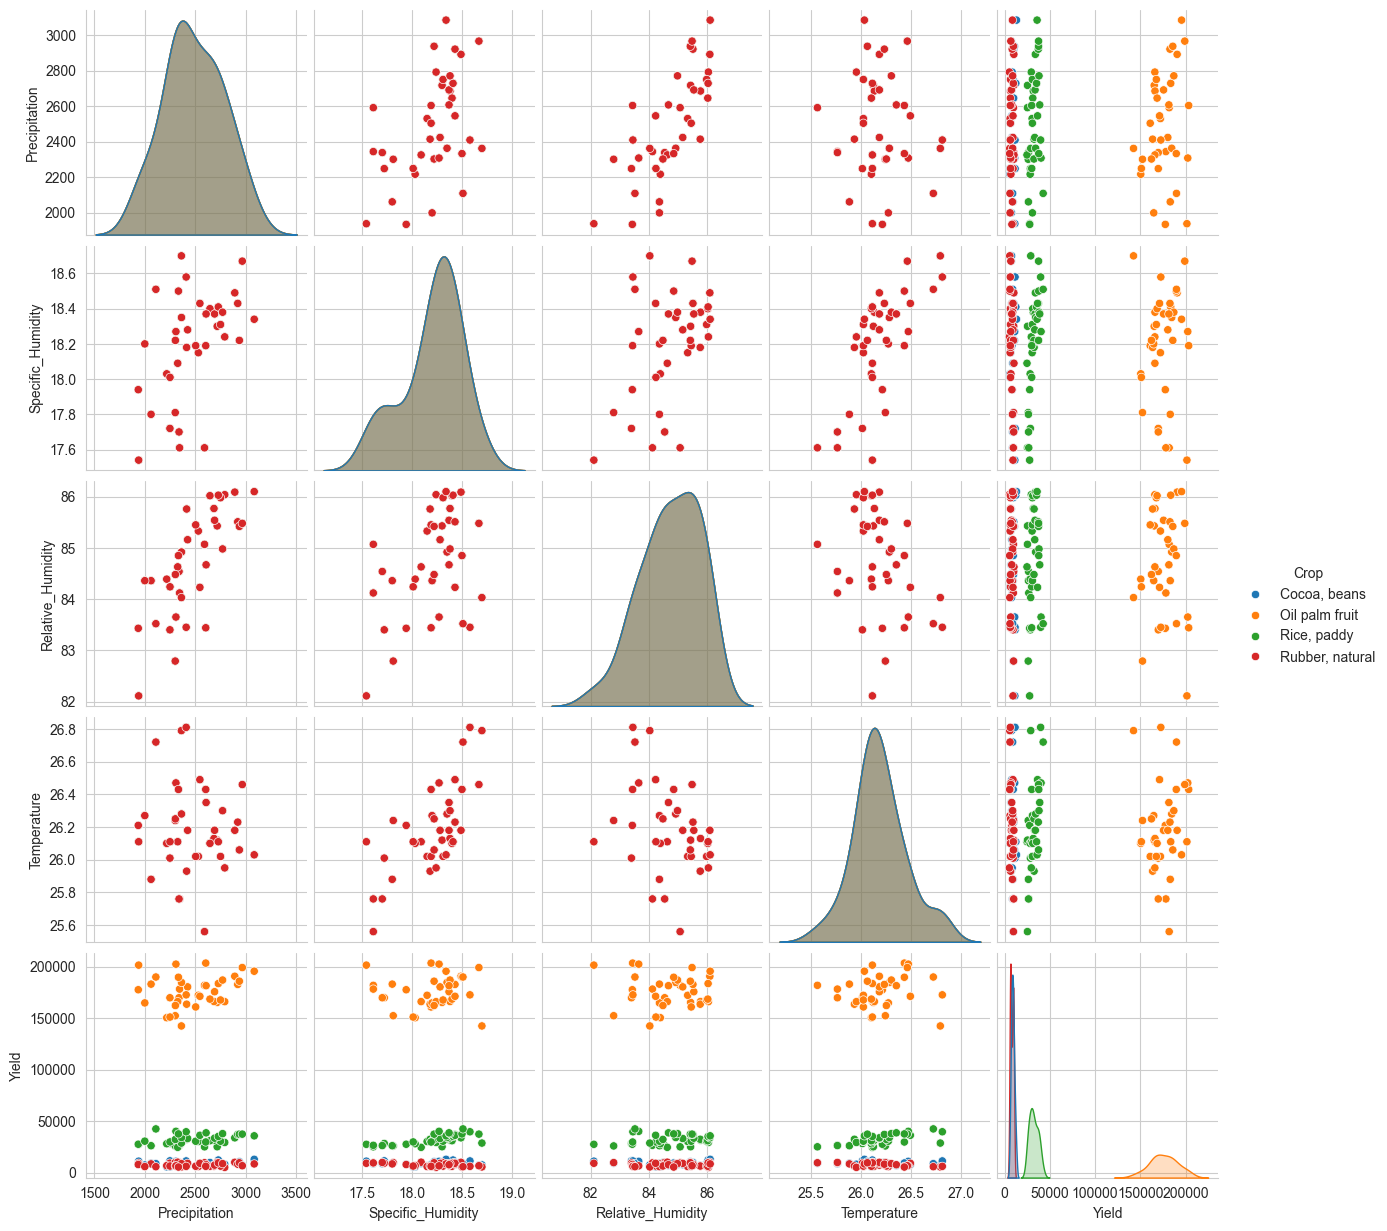

In [13]:
# Pairplot para visualizar relações entre variáveis numéricas
sns.pairplot(df, hue="Crop")
plt.show()


### 4.1 Principais achados da análise exploratória

A análise exploratória permitiu compreender a estrutura da base de dados e o comportamento inicial das variáveis relacionadas ao rendimento agrícola. Observou-se que o conjunto de dados é composto por diferentes culturas e por variáveis climáticas relevantes, como precipitação, umidade específica, umidade relativa e temperatura, além da variável-alvo de rendimento (`Yield`).

A distribuição das culturas mostrou como os registros estão organizados entre os diferentes tipos de plantação presentes na base. Essa verificação é importante, pois distribuições desbalanceadas entre culturas podem influenciar tanto a interpretação estatística quanto o desempenho dos modelos preditivos.

A análise da variável de rendimento revelou a dispersão dos valores observados, permitindo identificar a amplitude da produtividade agrícola no conjunto analisado. Dependendo do formato do histograma e do boxplot, pode-se observar concentração em determinadas faixas, presença de assimetria e possíveis valores discrepantes.

Ao avaliar a relação entre as variáveis numéricas e o rendimento, foi possível identificar tendências de associação entre condições ambientais e produtividade. A matriz de correlação auxiliou na identificação das variáveis com maior relação linear com o `Yield`, enquanto os gráficos comparativos permitiram perceber diferenças de comportamento entre culturas distintas.

De forma geral, a análise exploratória foi fundamental para orientar as etapas seguintes do projeto, especialmente no que se refere à clusterização, à identificação de outliers e à construção dos modelos de regressão.


## 5. Pré-processamento dos Dados

Antes de aplicar os algoritmos de Machine Learning, é necessário preparar os dados. Isso inclui o tratamento da variável categórica `Crop`, além da normalização dos atributos numéricos em etapas específicas do projeto.


In [14]:
# Cópia da base para preservar os dados originais
df_model = df.copy()

# Codificação da variável categórica Crop
label_encoder = LabelEncoder()
df_model["Crop"] = label_encoder.fit_transform(df_model["Crop"])

df_model.head()


,Crop,Precipitation,Specific_Humidity,Relative_Humidity,Temperature,Yield
0,0,2248.92,17.72,83.40,26.01,11560
1,0,1938.42,17.54,82.11,26.11,11253
2,0,2301.54,17.81,82.79,26.24,9456
3,0,2592.35,17.61,85.07,25.56,9321
4,0,2344.72,17.61,84.12,25.76,8800


## 6. Aprendizado Não Supervisionado — Clusterização

Nesta etapa, será aplicada uma técnica de clusterização para identificar agrupamentos naturais entre os cenários agrícolas, considerando as variáveis ambientais.

O objetivo é verificar se existem perfis distintos de condições de produção e se eles se relacionam com diferentes níveis de rendimento.


In [15]:
# ============================
# 3. Clusterização
# ============================

# Para clusterização, vamos usar apenas as variáveis numéricas de contexto
# e excluir o target Yield caso a ideia seja agrupar cenários sem "ensinar" o resultado.
X_cluster = df_model[["Crop", "Precipitation", "Specific_Humidity", "Relative_Humidity", "Temperature"]]

# Padronização
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

print("Dados preparados para clusterização.")


Dados preparados para clusterização.


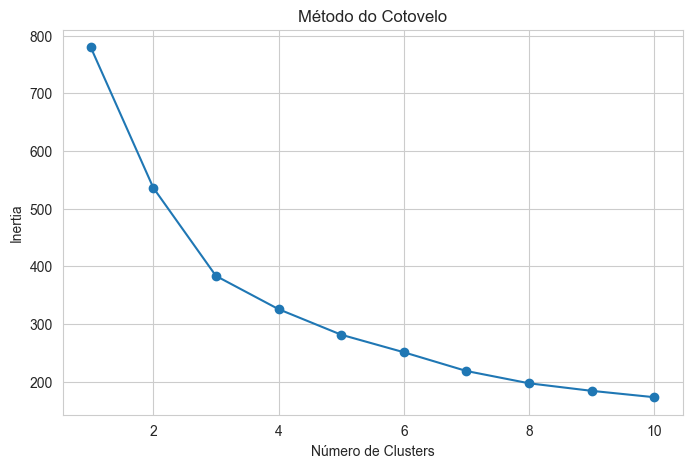

In [16]:
# Método do cotovelo para definição do número ideal de clusters
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia, marker="o")
plt.title("Método do Cotovelo")
plt.xlabel("Número de Clusters")
plt.ylabel("Inertia")
plt.show()


In [17]:
# Escolha do número de clusters
# Ajuste o valor de k conforme a interpretação do gráfico do cotovelo
k = 3

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)

df["Cluster"] = clusters
df_model["Cluster"] = clusters

print("Clusterização concluída.")
print("Silhouette Score:", silhouette_score(X_cluster_scaled, clusters))


Clusterização concluída.
Silhouette Score: 0.31868480551618245


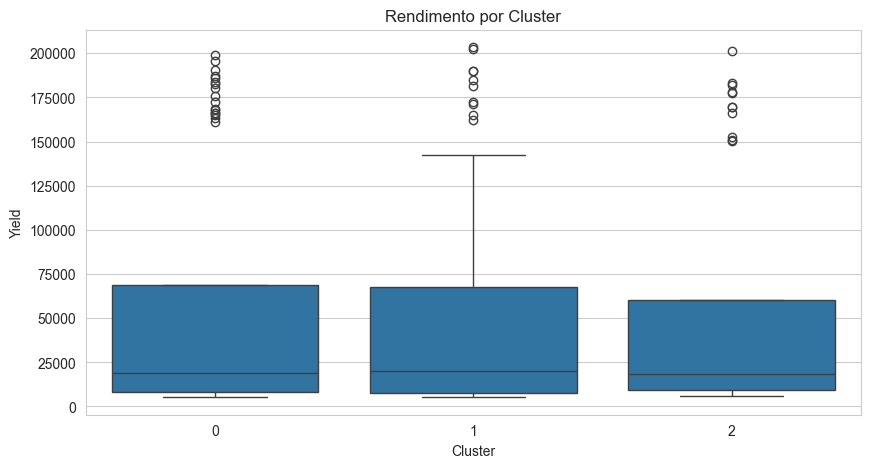

In [18]:
# Visualização dos clusters com relação ao rendimento
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="Cluster", y="Yield")
plt.title("Rendimento por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Yield")
plt.show()


In [19]:
# Médias das variáveis por cluster
df.groupby("Cluster")[["Precipitation", "Specific_Humidity", "Relative_Humidity", "Temperature", "Yield"]].mean()


,Precipitation,Specific_Humidity,Relative_Humidity,Temperature,Yield
Cluster,,,,,
0,2733.517647,18.337647,85.652353,26.118824,56736.544118
1,2359.024545,18.392727,84.145455,26.480909,57453.000000
2,2232.217273,17.805455,83.916364,25.986364,53951.500000


### 6.1 Interpretação dos clusters

A aplicação do algoritmo K-Means permitiu identificar agrupamentos naturais entre os cenários agrícolas presentes na base de dados. Para determinar o número ideal de clusters, foi utilizado o método do cotovelo, que analisa a redução da inércia à medida que novos grupos são adicionados ao modelo.

Observando o gráfico do método do cotovelo, percebe-se que a queda mais acentuada ocorre até aproximadamente três clusters, indicando que esse número representa um bom equilíbrio entre simplicidade do modelo e capacidade de separação dos dados. Dessa forma, optou-se pela utilização de **três clusters** para segmentar os cenários agrícolas.

A análise do rendimento por cluster mostra que os grupos apresentam distribuições relativamente semelhantes de produtividade, embora existam variações na dispersão dos valores dentro de cada cluster. Em todos os clusters é possível observar alguns valores de rendimento significativamente elevados, que aparecem como pontos extremos nos boxplots.

Esses agrupamentos indicam que os dados podem estar organizados em diferentes perfis de condições ambientais e de cultivo. No entanto, como as distribuições de rendimento entre os clusters são relativamente próximas, isso sugere que o rendimento agrícola não depende exclusivamente de um único conjunto específico de condições climáticas presentes na base analisada, mas sim de uma combinação mais complexa de fatores.

## 7. Identificação de Outliers

A detecção de outliers é importante para identificar cenários discrepantes, que podem representar situações raras, erros de medição ou condições extremas de produção.


In [20]:
# Detecção de outliers usando Z-score nas variáveis numéricas
numeric_columns = ["Precipitation", "Specific_Humidity", "Relative_Humidity", "Temperature", "Yield"]

z_scores = np.abs(zscore(df[numeric_columns]))
outliers = (z_scores > 3).any(axis=1)

df_outliers = df[outliers]
df_sem_outliers = df[~outliers]

print(f"Quantidade de outliers identificados: {df_outliers.shape[0]}")
df_outliers.head()


Quantidade de outliers identificados: 0


,Crop,Precipitation,Specific_Humidity,Relative_Humidity,Temperature,Yield,Cluster


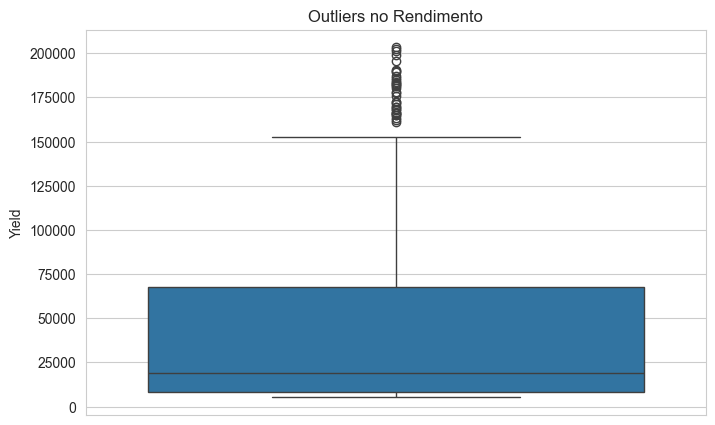

In [21]:
# Visualização dos outliers no rendimento
plt.figure(figsize=(8,5))
sns.boxplot(data=df, y="Yield")
plt.title("Outliers no Rendimento")
plt.show()


### 7.1 Interpretação dos outliers

Durante a análise dos dados foi possível identificar a presença de valores extremos no rendimento agrícola, evidenciados principalmente nos gráficos de boxplot. Esses pontos aparecem significativamente acima da faixa principal da distribuição e representam cenários com produtividade muito superior aos demais registros.

No contexto agrícola, esses valores podem refletir condições excepcionais de produção, como fatores climáticos altamente favoráveis, práticas agrícolas mais eficientes ou variações naturais entre culturas e safras. Portanto, nem sempre esses pontos devem ser considerados erros ou inconsistências nos dados.

Considerando o tamanho relativamente reduzido da base de dados utilizada neste projeto, optou-se por **manter os outliers no conjunto de dados**, evitando a remoção de possíveis cenários reais de alta produtividade. Essa decisão busca preservar a representatividade do conjunto de dados e evitar a perda de informações potencialmente relevantes para a modelagem.

Assim, os outliers foram analisados como parte natural da variabilidade dos dados, contribuindo para a compreensão da amplitude de rendimentos possíveis nas condições observadas.

## 8. Preparação para a Modelagem Supervisionada

Nesta etapa, os dados serão organizados para o treinamento e teste dos modelos de regressão. O target será a variável `Yield`.


In [22]:
# ============================
# 4. Preparação para regressão
# ============================

# Base para modelagem supervisionada
X = df_model.drop(columns=["Yield"])
y = df_model["Yield"]

# Separação em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Dados separados em treino e teste.")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


Dados separados em treino e teste.
X_train: (124, 6)
X_test: (32, 6)


In [23]:
# Padronização para modelos sensíveis à escala, como SVR
scaler_reg = StandardScaler()

X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)


## 9. Construção dos Modelos de Regressão

Serão desenvolvidos cinco modelos distintos para prever o rendimento da safra:

1. Regressão Linear
2. Árvore de Decisão
3. Random Forest
4. Support Vector Regressor (SVR)
5. Gradient Boosting Regressor

A comparação entre eles permitirá identificar qual algoritmo apresenta melhor desempenho para este problema.


In [24]:
# Função auxiliar para avaliar modelos
def avaliar_modelo(nome_modelo, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    return {
        "Modelo": nome_modelo,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }


In [25]:
resultados = []


In [26]:
# Modelo 1 - Regressão Linear
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

resultados.append(avaliar_modelo("Linear Regression", y_test, y_pred_lr))


In [27]:
# Modelo 2 - Árvore de Decisão
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

resultados.append(avaliar_modelo("Decision Tree", y_test, y_pred_dt))


In [28]:
# Modelo 3 - Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

resultados.append(avaliar_modelo("Random Forest", y_test, y_pred_rf))


In [29]:
# Modelo 4 - SVR
svr = SVR()
svr.fit(X_train_scaled, y_train)
y_pred_svr = svr.predict(X_test_scaled)

resultados.append(avaliar_modelo("SVR", y_test, y_pred_svr))


In [30]:
# Modelo 5 - Gradient Boosting
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)

resultados.append(avaliar_modelo("Gradient Boosting", y_test, y_pred_gbr))


## 10. Avaliação e Comparação dos Modelos

Os modelos serão comparados com base nas seguintes métricas:

- **MAE (Mean Absolute Error):** erro médio absoluto;
- **MSE (Mean Squared Error):** erro quadrático médio;
- **RMSE (Root Mean Squared Error):** raiz do erro quadrático médio;
- **R² (Coeficiente de Determinação):** indica o quanto o modelo explica a variabilidade dos dados.

Modelos com **menor erro** e **maior R²** tendem a apresentar melhor desempenho.


In [31]:
# Tabela comparativa dos modelos
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by="R2", ascending=False).reset_index(drop=True)

df_resultados


,Modelo,MAE,MSE,RMSE,R2
0,Random Forest,2743.986250,2.179741e+07,4668.769420,0.994381
1,Decision Tree,3011.437500,2.431486e+07,4931.010102,0.993732
2,Gradient Boosting,3041.971973,2.673382e+07,5170.476051,0.993108
3,Linear Regression,56122.628687,4.484813e+09,66968.742855,-0.156186
4,SVR,38973.744137,5.085598e+09,71313.376558,-0.311069


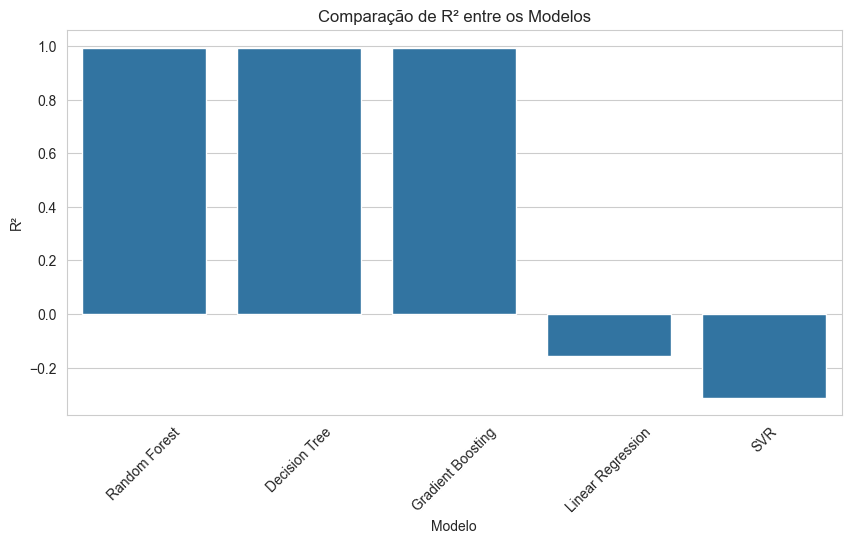

In [32]:
# Gráfico comparando R²
plt.figure(figsize=(10,5))
sns.barplot(data=df_resultados, x="Modelo", y="R2")
plt.title("Comparação de R² entre os Modelos")
plt.xlabel("Modelo")
plt.ylabel("R²")
plt.xticks(rotation=45)
plt.show()


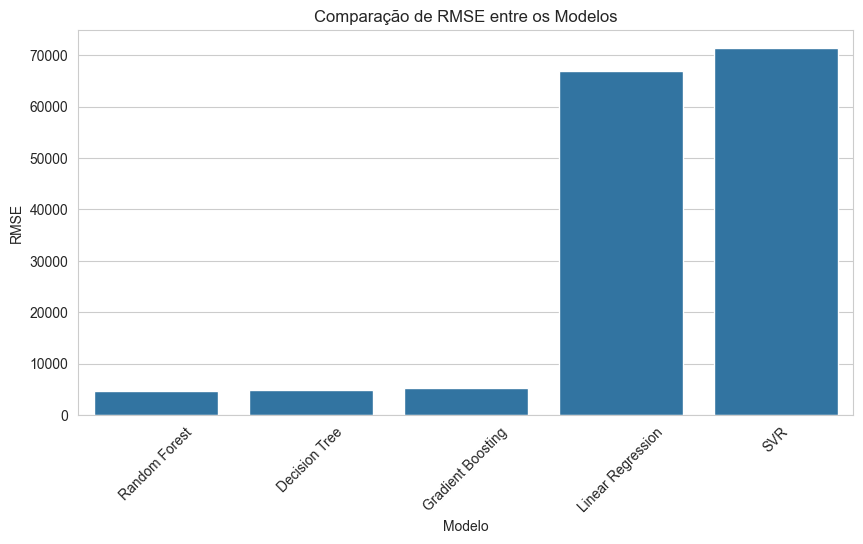

In [33]:
# Gráfico comparando RMSE
plt.figure(figsize=(10,5))
sns.barplot(data=df_resultados, x="Modelo", y="RMSE")
plt.title("Comparação de RMSE entre os Modelos")
plt.xlabel("Modelo")
plt.ylabel("RMSE")
plt.xticks(rotation=45)
plt.show()


### 10.1 Interpretação dos resultados dos modelos

A etapa de modelagem supervisionada comparou cinco algoritmos de regressão diferentes para prever o rendimento agrícola a partir das variáveis disponíveis na base de dados. Os modelos foram avaliados com base em métricas de erro e no coeficiente de determinação (R²), permitindo identificar qual abordagem apresentou melhor desempenho preditivo.

Entre os modelos testados, o **Random Forest Regressor** apresentou o melhor desempenho geral, com R² de aproximadamente **0.994**, indicando uma alta capacidade de explicar a variabilidade do rendimento presente no conjunto de dados. Além disso, apresentou erros menores em comparação com os demais modelos, refletidos em valores mais baixos de MAE e RMSE.

O modelo **Decision Tree Regressor** também apresentou desempenho elevado, com R² próximo de **0.993**, seguido pelo **Gradient Boosting Regressor**, que apresentou resultados semelhantes. Esses modelos baseados em árvores de decisão demonstraram grande capacidade de capturar relações não lineares entre as variáveis climáticas e o rendimento agrícola.

Por outro lado, os modelos **Linear Regression** e **Support Vector Regressor (SVR)** apresentaram desempenho significativamente inferior. Em especial, o coeficiente de determinação negativo observado nesses modelos indica que suas previsões foram menos precisas do que simplesmente utilizar a média dos valores de rendimento da base. Esse comportamento sugere que as relações entre as variáveis do problema não são adequadamente representadas por modelos lineares simples ou pela configuração padrão do SVR utilizada.

De forma geral, os resultados indicam que modelos baseados em árvores e ensembles são mais adequados para capturar os padrões presentes neste conjunto de dados, provavelmente devido à capacidade de lidar com relações complexas e não lineares entre variáveis ambientais e produtividade agrícola.

In [34]:
# Importância das variáveis com Random Forest
importancias = pd.DataFrame({
    "Variavel": X.columns,
    "Importancia": rf.feature_importances_
}).sort_values(by="Importancia", ascending=False)

importancias


,Variavel,Importancia
0,Crop,0.986720
2,Specific_Humidity,0.004441
1,Precipitation,0.003630
4,Temperature,0.003268
3,Relative_Humidity,0.001826
5,Cluster,0.000115


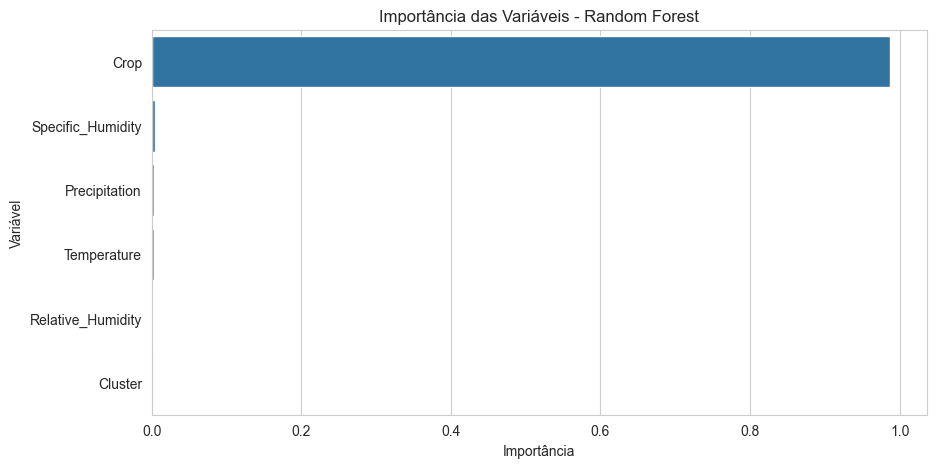

In [35]:
# Gráfico de importância das variáveis
plt.figure(figsize=(10,5))
sns.barplot(data=importancias, x="Importancia", y="Variavel")
plt.title("Importância das Variáveis - Random Forest")
plt.xlabel("Importância")
plt.ylabel("Variável")
plt.show()


### 10.2 Importância das variáveis
A análise de importância das variáveis foi realizada utilizando o modelo Random Forest, que permite estimar a contribuição relativa de cada atributo na previsão do rendimento.

O resultado mostrou que a variável **Crop (tipo de cultura)** possui uma importância significativamente maior em comparação com as demais variáveis do conjunto de dados. Esse comportamento indica que o tipo de cultura cultivada exerce forte influência sobre o rendimento observado, superando o impacto das variáveis climáticas analisadas.

As variáveis ambientais, como precipitação, temperatura e umidade, apresentaram importância muito menor no modelo treinado. Esse resultado pode indicar que, dentro da base de dados analisada, a variação de rendimento está mais associada às características próprias de cada cultura do que às diferenças nas condições climáticas registradas.

Esse achado reforça a importância de considerar o tipo de cultura como fator central na previsão de produtividade agrícola e sugere que, para análises mais detalhadas, seria interessante incorporar variáveis adicionais relacionadas ao manejo agrícola e às características do solo.


## 11. Conclusão

Este projeto teve como objetivo analisar dados ambientais e agrícolas para identificar padrões de produtividade e desenvolver modelos capazes de prever o rendimento de safras utilizando técnicas de Machine Learning.

Inicialmente, a análise exploratória permitiu compreender a estrutura da base de dados e identificar padrões relevantes entre as variáveis climáticas, o tipo de cultura e o rendimento agrícola. Em seguida, técnicas de aprendizado não supervisionado foram aplicadas para segmentar os dados em diferentes clusters, permitindo observar possíveis agrupamentos de cenários produtivos.

Na etapa de modelagem supervisionada, foram testados cinco algoritmos de regressão diferentes. Entre eles, os modelos baseados em árvores, especialmente o **Random Forest**, apresentaram desempenho superior, com elevada capacidade de explicar a variabilidade do rendimento agrícola presente na base de dados.

Além disso, a análise de importância das variáveis revelou que o tipo de cultura desempenha papel fundamental na determinação do rendimento observado, apresentando impacto significativamente maior que as variáveis climáticas analisadas.

De forma geral, os resultados demonstram o potencial da aplicação de técnicas de Ciência de Dados e Machine Learning no contexto agrícola, permitindo transformar dados ambientais em informações úteis para análise e previsão de produtividade.

Obs: Apesar do alto desempenho obtido por alguns modelos, especialmente o Random Forest, é importante considerar que o tamanho reduzido da base de dados pode favorecer resultados elevados de ajuste. Em cenários reais, bases maiores e mais variadas são recomendadas para garantir maior capacidade de generalização dos modelos.

## 12. Limitações e Trabalhos Futuros

Apesar dos resultados obtidos, este projeto apresenta limitações que devem ser consideradas na interpretação dos achados. A principal delas está relacionada ao tamanho reduzido da base de dados, o que pode restringir a capacidade de generalização dos modelos e aumentar a sensibilidade a oscilações específicas do conjunto analisado.

Além disso, o número de variáveis disponíveis é relativamente limitado para representar toda a complexidade do ambiente agrícola. Fatores como tipo de solo, incidência solar, manejo da lavoura, fertilização, histórico da área plantada e ocorrência de pragas, por exemplo, também podem influenciar significativamente o rendimento e não estão contemplados nesta base.

Outro ponto importante é que a análise foi realizada com foco em um conjunto específico de registros, o que significa que os resultados devem ser interpretados como uma aproximação analítica do problema, e não como uma solução definitiva pronta para aplicação direta em produção.

Como trabalhos futuros, seria recomendável ampliar a base de dados, incluir novas variáveis agronômicas, aplicar validação cruzada, testar ajuste fino de hiperparâmetros e investigar modelos adicionais. Também seria interessante incorporar séries temporais e informações históricas de produção, o que poderia aumentar a robustez das previsões e gerar insights ainda mais relevantes para o contexto agrícola.



## 13. Considerações Finais

A solução desenvolvida neste notebook demonstra como a integração entre análise de dados, clusterização e regressão pode contribuir para o entendimento e a previsão do rendimento agrícola. Ao longo do projeto, foi possível transformar dados brutos em informações úteis, explorando tanto padrões ocultos quanto capacidade preditiva.

Nesse sentido, a proposta da FarmTech Solutions se mostrou alinhada ao uso estratégico da Inteligência Artificial no agronegócio, evidenciando como dados ambientais podem apoiar decisões mais inteligentes, eficientes e orientadas por evidências.
